# Precipitation Model Testing Using Data Cesar and Radiometer data

This Jupyter Notebook tests a precipitation model using measurements from Cabauw as input.

The current version of the model requires the following meteorological inputs at each model time step:

#### Required Inputs

- **Surface Inputs** (from Meteo Surface Cabauw ):
  - Surface air temperature
  - Surface pressure
  - Surface dew point temperature

- **Atmospheric Profile Inputs** (from MWR Radiometer at Cabauw):
  - Temperature at height levels
  - Specific humidity at height levels

These inputs are used to simulate the evolution of the model state, which is the  **Cloud column liquid water**, including:
- How it evolves over time
- How much is converted to rainwater
- How much reaches the ground as precipitation

To estimate precipitation, all of the above input variables must be provided at each timestep.

#### Data Sources

- **Cesar Network Cabauw Meteo surface** (KNMI): for surface temperature, dew point, and pressure  
- **Cloudnet MWR multiple pointing Cabauw** (FMI): for vertical profiles of temperature and specific humidity

#### Data Preparation

The input datasets are preprocessed and combined externally using the notebook:

```bash
preparing_radiometer_data.ipynb

In [156]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh,w_sat
import profiles_and_cloud_heights as profiles
from constants import g,alpha
import interpolation_lcl as interp
from autoconversion_rate import thresh
import autoconversion_rate as ar
from entrainment import lcl_enrtainment_from_ground
import condensation_fluxes
import updraft_emmanuel
import new_rainfall_scheme as nr
import top_outflow as outflow


## Table of Contents

1. [Loading the data](#Loading-the-data)
2. [Running the model](#Running-the-model)
3. [Visualizing the outputs](#Visualizing-the-outputs)


## Loading the Data

Interactive cell for initializing the model settings. Choose the desired values, click Apply Settings and then Run All cells again or Run below.

In [157]:
%run widgets.py

Choose the time interval for which the model is to be run.

The input data used in this model consist of a combined dataset derived from the **Cesar Network surface data** and **Cloudnet MWR profiles** corresponding to Cabauw.

- **Surface variables** include:
  - Surface air temperature
  - Surface pressure
  - Surface dew point temperature

- **Atmospheric profile variables** include:
  - Temperature at multiple height levels
  - Specific humidity at those levels

After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.

In [158]:
#load the datasets -radiometer profiles
cabauw_data = xr.open_mfdataset(r'..\data\model_inputs\Cabauw_radiometer\radiometer_profile_data.nc')
cabauw_data = cabauw_data.sel(time=slice(*slice_tuple))

Storing the time values and the timestep.

In [159]:

time = cabauw_data.sel(time=slice(*slice_tuple)).time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Environmental profiles and inputs

The model inputs

In [160]:
T_air = cabauw_data.temperature.values
p_air = cabauw_data.pressure.values
T_d = cabauw_data.dew_point_temperature.values
q_v_air = cabauw_data.specific_humidity.values
Z = cabauw_data.height.values

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [161]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


#hourly average
rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


## Running the model

### Parcel Profiles

Store the sizes for creating empty arrays

In [162]:
rows = T_air.shape[0]
cols = T_air.shape[1]

#### Initializing Model Output Arrays

Empty arrays are created to store the outputs of the model. These arrays are initialized with dimensions either `(time, height)` or `(time)`, depending on the variable.

**Main Model Outputs**
- **`temp_parcel`**: The parcel temperature profile, computed by solving the model’s thermodynamic equations.
- **`T_v_moist`**: The virtual temperature profile of the parcel.
- **`q_v_parcel`**: The specific humidity profile of the parcel.

**LCL Parameters** 
- **`p_s`**: LCL pressure.
- **`T_s`**: LCL temperature.
- **`lcl_index`**: Index of the lifting condensation level (LCL) in the vertical profile.

**Expanded Environmental Profiles**
All other arrays are expanded to `(time, height + 1)` to include the LCL explicitly in the profiles. This ensures that the exact values of the meteorological variables at the LCL level are stored and used in calculations.


In [163]:
## empty arrays for storing the meteorological profiles
temp_parcel = np.zeros(T_air.shape) #parcel temperature profile (time, height)
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel_new = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
air_temp_new = np.zeros((rows,cols+1))   # new air temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


#### Implementing the Model: Temperature and Humidity Profiles

This section implements the model functions used to calculate the **parcel's temperature and humidity profiles**. For the temperature profile calculation, the user can select among several conserved quantity approaches:

- `'theta_e'` — Pseudoadiabatic equivalent potential temperature  
- `'theta_l'` — Reversible liquid water potential temperature  
- `'theta_e_reversible'` — Reversible equivalent potential temperature  
- `'GB84'` — Pseudoadiabatic equivalent potential temperature (as defined in Georgakakos and Bras, 1984a)

**Calculation Workflow**

1. *Parcel Temperature and LCL Variables*  
   Using the `profiles_and_cloud_heights.py` module, the parcel temperature profile is computed along with key LCL (Lifting Condensation Level) variables.

2. *Interpolation at the LCL* 
   The `interpolation_lcl.py` module is then used to interpolate both the parcel and environmental profiles so that all relevant meteorological variables are available at the exact height of the LCL.

3. *Parcel Humidity and Virtual Temperature* 
   Finally, with the updated profiles, `profiles_and_cloud_heights.py` is used again to calculate the parcel's specific humidity and virtual temperature profiles.



In [164]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

for i in range(0,T_air.shape[0]):

    #calculating the profiles
    q_t = w_sat(T_d[i],p_air[i,0])
    temp_parcel[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.calculate_parcel_Temp_profile(T_air[i,0],p_air[i,0],T_d[i],p_air[i],theta_type=theta_type)

    #interpolation at the lcl level
    temp_parcel_new[i], p_new[i], Z_new[i], lcl_index[i], air_temp_new[i], q_v_new[i] = interp.insert_lcl_values(temp_parcel[i],p_air[i],Z,int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.calculate_parcel_T_v_profile(T_d[i],p_new[i],temp_parcel_new[i,:],int(lcl_index[i]),theta_type=theta_type)

In [165]:
negs = (q_v_parcel < 0).sum()
print(f"Number of negative values in q_l_new: {negs}")

Number of negative values in q_l_new: 0


#### Calculate the environmental virtual temperature profiles

In [166]:
# environmental virtual temperature profile
T_v_env = air_temp_new*(1+0.61*q_v_new)

### Cloud Heights

#### Determining the Location of the LFC

This step calculates the **Level of Free Convection (LFC)**, indicated by the `lfc_index`. The goal is to determine whether the parcel can reach the LFC based on its thermodynamic state.

- If the conditions allow the parcel to become positively buoyant and reach the LFC, the first entry of the `LFC_index` variable is marked as `"yes"` and a value of `1` is stored.
- If the parcel cannot reach the LFC, the entry is marked as `"no"` and a value of `0` is stored.

This check ensures the model accurately tracks whether convection is initiated in each timestep.


In [167]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0


#### Determining the cloud top and cloud depth
Finding the **cloud top height** and **pressure** and the **resulting cloud depth**, again by calling `profiles_and_cloud_heights.py`.

In [168]:
#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist[i],T_v_env[i],temp_parcel_new[i])


### Entrainment calculations

Cell that automatically selects the correct index of cloud height to implement entrainment from, based on the user selection

In [169]:
if entrainment_beginning=='from LCL':
    start_index = lcl_index + 1
elif entrainment_beginning=='from ground':
    start_index = np.ones(lcl_index.shape[0])

Updating the parcel profiles of temperature and humidity, this time taking entrainment into account 

In [170]:
#from profiles_and_cloud_heights import profiles_with_entrainment
T_parcel_new = np.zeros((rows,cols+1)) 
q_t_parcel_new = np.zeros((rows,cols+1))

for i in range(0,rows):
    #print(i)
    entrainment_rate = min(0.001,1/Z_c[i])     #Siebesma et al. (2003)
    T_parcel_new[i],q_t_parcel_new[i] = profiles.calculate_profiles_with_entrainment(T_s[i], T_d[i], air_temp_new[i], temp_parcel_new[i], p_s[i], p_new[i], q_v_new[i], Z_new[i,], int(start_index[i]), entrainment_rate, theta_type)


c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\scipy\optimize\_minpack_py.py:177: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


In [171]:
q_l_new = np.zeros((rows,cols+1))
q_v_parcel_new = 1*q_v_parcel

for i in range(0,rows):
    #print(i)
    entrainment_rate = min(0.001,1/Z_c[i]) 
    q_l_new[i],q_v_parcel_new[i] = profiles.calculate_humidity_profiles_with_entrainment(q_t_parcel_new[i],p_new[i],T_parcel_new[i],T_d[i],int(start_index[i]))
    
    # if entrainment starts from the ground, then the LCL changes so it has to be recalculated and interpolated
    if entrainment_beginning=='from ground':
        
        temp_parcel[i] = np.delete(T_parcel_new[i],int(lcl_index[i]))
        p_air[i] = np.delete(p_new[i],int(lcl_index[i]))
        Z = np.delete(Z_new[i],int(lcl_index[i]))
        T_air[i] = np.delete(air_temp_new[i],int(lcl_index[i]))
        q_v_air[i] = np.delete(q_v_new[i],int(lcl_index[i]))

        lcl_index[i],T_s[i],p_s[i] = lcl_enrtainment_from_ground(T_parcel_new[i],p_new[i],T_d[i],Z_new[i])
        lcl_index[i] = np.clip(int(lcl_index[i]), 0, len(p_air[i]) - 3)     #for cases where the LCL is in very high altitude

        #interpolation at the lcl level
        T_parcel_new[i], p_new[i], Z_new[i], lcl_index[i], air_temp_new[i], q_v_new[i] = interp.insert_lcl_values(temp_parcel[i],p_air[i],Z,int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])
    



Calculating the new parcel virtual temperature profile after considering entrainment 

In [172]:
if theta_type=='theta_e' or theta_type=='GB84':
    T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new)
else:
    T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new- q_l_new)

#### LFC height

Calculating the location of the LFC, which is given by the lfc_index, as well as if the conditions allow the parcel to reach it. If so, then the first value of the LFC_index variable will print "yes" and we are storing 1. Otherwise, we get "no" and 0 is stored.

In [173]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist_new[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

#### Determining the cloud top and cloud depth
Finding the **cloud top height** and **pressure** and the **resulting cloud depth**, again by calling `profiles_and_cloud_heights.py`.

In [174]:
#empty arrays for storing the outputs
Z_c_new = np.zeros(rows)
Z_t_new = np.zeros(rows)
p_t_new = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c_new[i],Z_t_new[i],p_t_new[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist_new[i],T_v_env[i],T_parcel_new[i])

In [175]:
def find_top_index(Z_t_new,Z_c_new,Z_new):
    if Z_t_new == 0 or Z_c_new == 1:  
        top_index = 0
    else:
         top_index = np.argmax((Z_t_new - Z_new) <= 0)
    return top_index

### Updraft speed

Using the parcel and environmental virtual temperature profiles, we calculate the parcel **updraft velocity profile** by calling the `updraft_emmanuel.py`. To do so, we have to first find the index of cloud top height. 

In [176]:
#import updraft_emmanuel

w_parcel_max= np.zeros(rows)
for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])
    w_parcel_max[i],CAPE = updraft_emmanuel.calculate_parcel_updraft_velocity(Z_new[i],T_v_moist_new[i],T_v_env[i],LFC_index[i,1],top_index)

In [191]:
indices = np.where(w_parcel_max>0)[0]   
np.mean(w_parcel_max[indices]/2)

2.3327241709590614

### State calculation and update

#### Calculating the Temporal Evolution of the Cloud System

This section computes the **state evolution of the cloud system over time**. The evolution focuses on changes in cloud liquid water content due to condensation and precipitation processes.

**Components of the Moisture Budget**

- *Condensation (Inflow)*  
  The amount of condensed water within the cloud is calculated using the `GB84.py` module, based on the approach of Georgakakos and Bras (1984).

- *Outflow (Losses)*  
  Moisture outflow from the cloud includes:
  - *Rainwater formation*: Determined via the `autoconversion_rate.py` module, which estimates the rate at which cloud water is converted to rain.
  - *Droplet removal by updrafts*: Handled by the `top_outflow.py` module, representing the loss of cloud droplets entrained by upward-moving air.

Together, these components allow the model to track the cloud water budget and estimate precipitation over time.


In [177]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)


for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])  

    w_avg = w_parcel_max[i]/2
    rho = condensation_fluxes.rho_m(T_s[i],T_parcel_new[i,top_index],p_s[i],p_t_new[i])
    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr[i] = 0
    else:
        f_arr[i] = condensation_fluxes.condensation_flux(rho,w_avg,q_l_new[i],int(lcl_index[i]),top_index,theta_type=theta_type)

    if i<rows-1:
        #if X[i]/Z_c_new[i] > 2.5e-3:        #capping the X values so that they don't abnormally high
            #X[i] = 2.5e-3*Z_c_new[i]

    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - ar.cloud_water_autoconversion_rate(X[i],Z_c_new[i],thresh)*dt_seconds[i]# - outflow.calculate_water_top_outflow(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        X[i+1] = max(0,X[i+1])


In [193]:
np.mean(f_arr)

0.007350946948608539

In [194]:
total_water = np.zeros(rows)
for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])
    if theta_type == "GB84" or theta_type == "theta_e":         #in pseudoadiabatic approach water is constantly removed, 
        total_water[i] = np.sum(q_l_new[i,int(lcl_index[i]):int(top_index)+1])                                                   #so integrate over all cloud heights
    
    else:                                                       #in reversible approach water is staying inside the parcel,
        total_water[i] = q_l_new[i,int(top_index)]    

np.mean(total_water)

0.0020428115474503566

### Rainfall rates

#### Precipitation Rate Calculation at Ground Level

The process to calculate the precipitation rate reaching the ground involves multiple steps:

- **Rainfall Rate from Cloud:**  
   The initial rate of rainfall exiting the cloud is determined by executing the script `autoconversion_rate.py`.

- **Rain Droplet Size Distribution:**  
   Using the calculated rainfall rate, the script `new_rainfall_scheme.py` assumes and computes a raindrop size distribution.

- **Estimation of Surface Precipitation:**  
   Based on the droplet size distribution, the model estimates the fraction of raindrops that survive evaporation during their descent and subsequently reach the ground as precipitation.


In [178]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    #print(i)
    rho = condensation_fluxes.rho_m(T_s[i],T_parcel_new[i,top_index],p_s[i],p_t_new[i])
    R[i] = ar.cloud_water_autoconversion_rate(X[i],Z_c_new[i],thresh)
    if R[i]<=2.7e-5:      #excluding precipitation rates below 0.1 mm/h due to numerical issues
        P[i] = 0
    else:
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_parcel_max[i]/2*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        #print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(T_parcel_new[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c_new[i],w_parcel_max[i]/2*100).calculate_evaporation_critical_diameter()
        P[i] = nr.ground_precipitation_rate(R[i], mu_result, Lambda_result, D_critical*100,w_parcel_max[i]/2*100,alpha)

## Visualizing the outputs

#### Rainfall rate

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

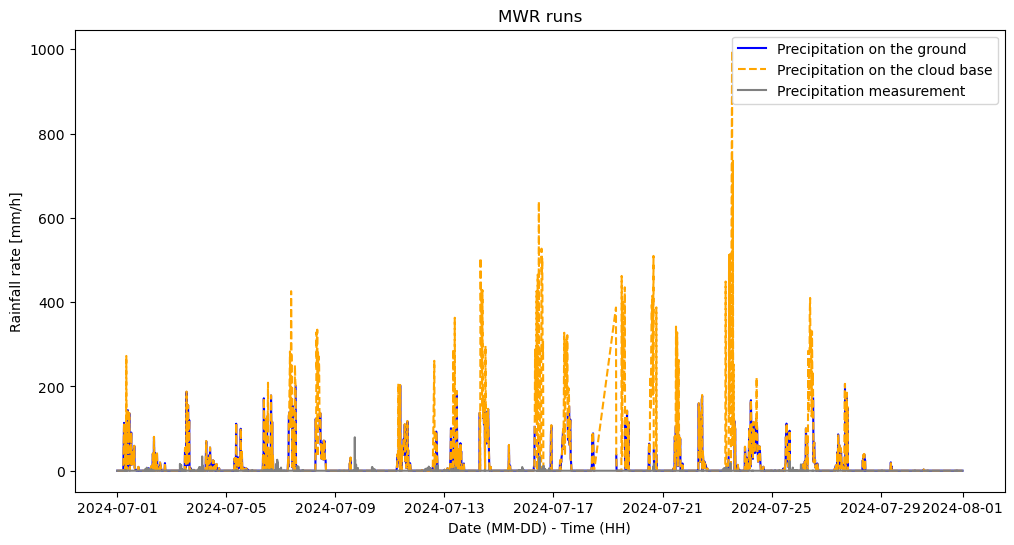

In [179]:
plt.figure(figsize=(12,6))
plt.title('MWR runs')
plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
plt.plot(time,R*3600,color='orange',linestyle='--',label='Precipitation on the cloud base')
plt.plot(rain_rate.time,rain_rate,color='gray',label='Precipitation measurement')
plt.legend()
plt.ylabel('Rainfall rate [mm/h]')
plt.xlabel('Date (MM-DD) - Time (HH)')

In [180]:
import pickle
import pandas as pd
import numpy as np
from datetime import datetime

# Method 1: Save as pickle (preserves exact Python objects including datetime)
def save_datasets_pickle():
    """Save all datasets as pickle files"""
    datasets = {
        'rain_rate': rain_rate,
        'time': time,
        'R': R,
        'Z_t': Z_t,
        'Z_t_new': Z_t_new,
        'T_v_env': T_v_env,
        'T_v_moist_new': T_v_moist_new,
        'Z_new': Z_new,
        'metadata': {
            'theta_type': theta_type,
            'entrainment_beginning': entrainment_beginning,
            'slice_str': slice_str,
            'slice_tuple': slice_tuple,
            'start_dt': start_dt,
            'end_dt': end_dt,
            'save_timestamp': datetime.now().isoformat()
        }
    }
    
    with open('radiometer_datasets.pkl', 'wb') as f:
        pickle.dump(datasets, f)
    
    print("✓ Datasets saved as radiometer_datasets.pkl")

In [181]:
save_datasets_pickle()

✓ Datasets saved as radiometer_datasets.pkl


#### Virtual Temperature profiles at different times

In [182]:
nearest_time = '2024-07-19T00'
selected = time.sel(time=nearest_time, method='nearest')

# Get the index of the nearest time
index_1 = int(time.get_index('time').get_loc(selected.time.values))

nearest_time_2 = '2024-07-19T12'
selected_2 = time.sel(time=nearest_time_2, method='nearest')

# Get the index of the nearest time
index_2 = int(time.get_index('time').get_loc(selected_2.time.values))

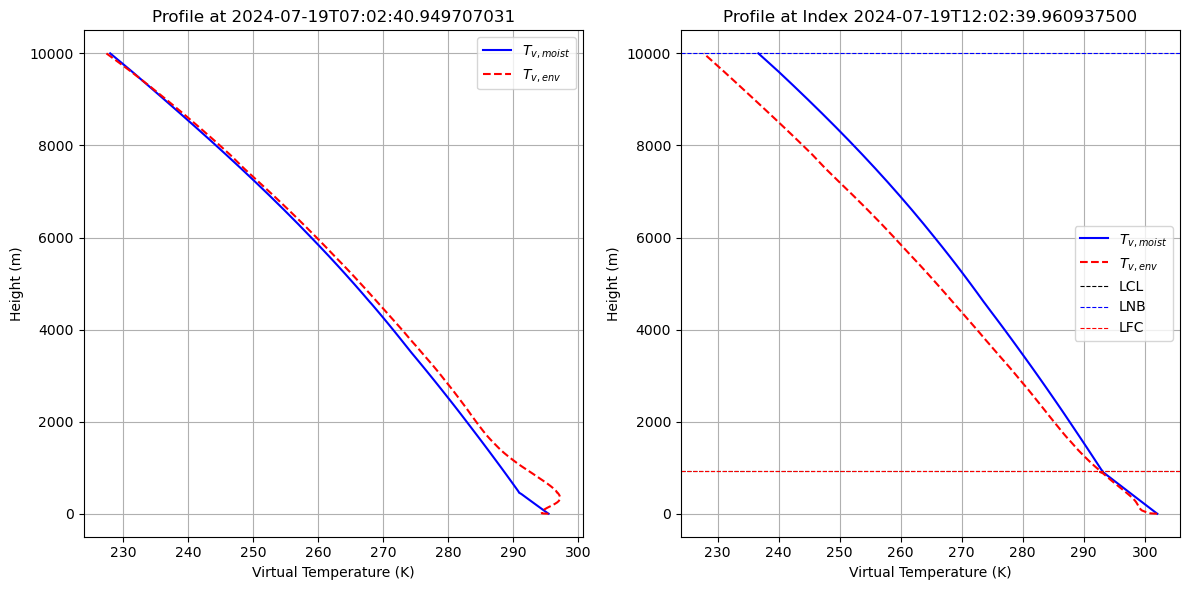

In [183]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
index_1 = index_1
index_2 = index_2

# Subplot 1: For index 1
ax1.plot(T_v_moist[index_1], Z_new[index_1], label='$T_{v,moist}$', color='blue')
ax1.plot(air_temp_new[index_1] * (1 + 0.61 * q_v_new[index_1]), Z_new[index_1], 
        label='$T_{v,env}$', color='red', linestyle='--')
ax1.set_xlabel('Virtual Temperature (K)')
ax1.set_ylabel('Height (m)')
ax1.set_title(f'Profile at {time[index_1].values}')
ax1.legend()
ax1.grid(True)

# Subplot 2: For index 2
ax2.plot(T_v_moist[index_2], Z_new[index_2], label='$T_{v,moist}$', color='blue')
ax2.plot(air_temp_new[index_2] * (1 + 0.61 * q_v_new[index_2]), Z_new[index_2], 
        label='$T_{v,env}$', color='red', linestyle='--')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.axhline(y=Z[int(lcl_index[index_2])], color='black', linestyle='--',linewidth='0.8',label='LCL')
ax2.axhline(y=Z_t[index_2], color='blue', linestyle='--',linewidth='0.8',label='LNB')
ax2.axhline(y=Z[int(LFC_index[index_2,1])], color='red', linestyle='--',linewidth='0.8',label='LFC')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.set_ylabel('Height (m)')
ax2.set_title(f'Profile at Index {time[index_2].values}')
ax2.legend()
ax2.grid(True)

plt.tight_layout()  # Prevents overlapping labels
plt.show()
#plt.ylim(Z[lcl_index],Z[LFC_index[1]+2])#,Z[LFC_index[1]+2])
#plt.ylim(0,100#### Cloud top and base0)

#### Cloud top and base

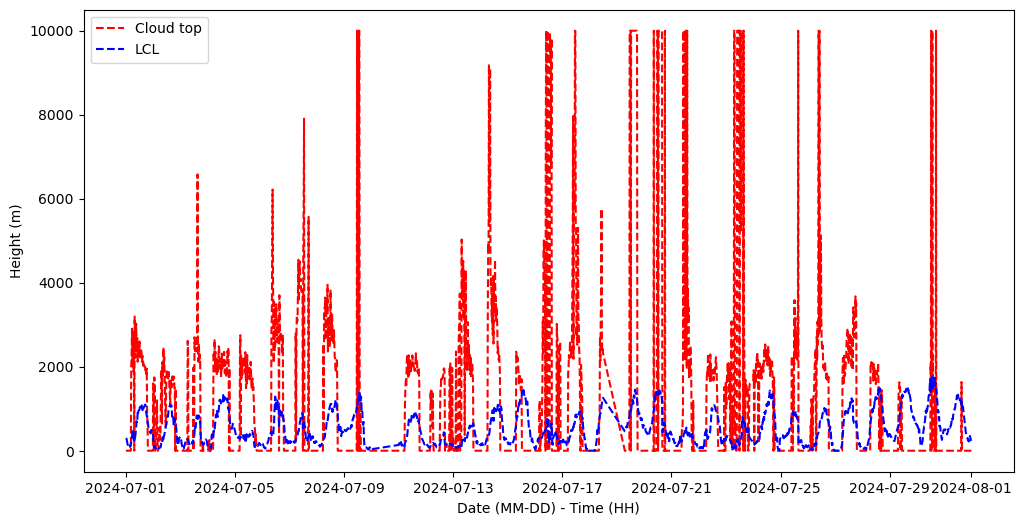

In [184]:
plt.figure(figsize=(12,6))
plt.plot(time,Z_t,color='red',linestyle='--',label='Cloud top')
plt.plot(time,Z_new[np.arange(Z_new.shape[0]),lcl_index.astype(int)],color='blue',linestyle='--',label='LCL')
plt.ylabel('Height (m)')
plt.xlabel('Date (MM-DD) - Time (HH)')
plt.legend()

#### Updraft velocity

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

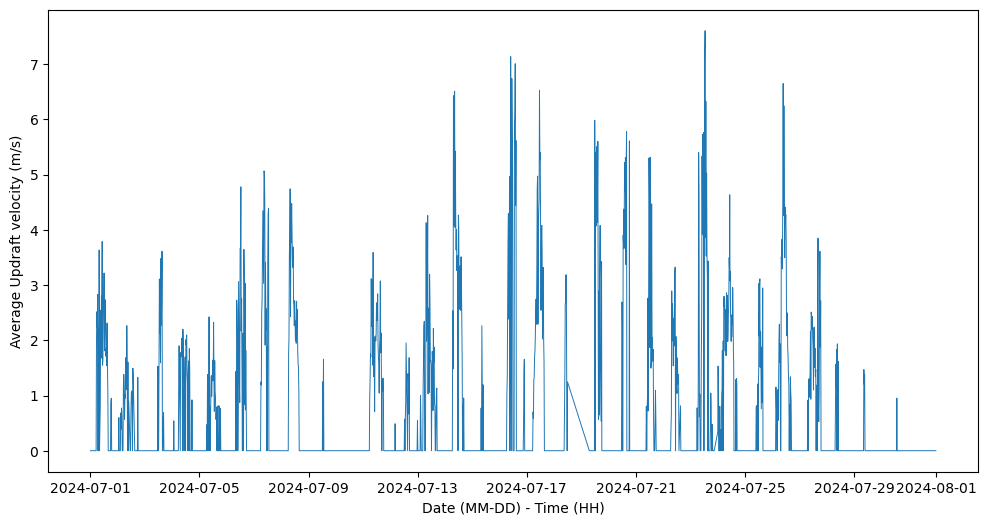

In [185]:
plt.figure(figsize=(12,6))
plt.plot(time,w_parcel_max/2,linewidth=0.7)
plt.ylabel('Average Updraft velocity (m/s)')
plt.xlabel(('Date (MM-DD) - Time (HH)'))

In [186]:
indices = np.where(R*3600>0)
np.mean(w_parcel_max[indices]/2)

1.6702573285024982

#### LWC and LWP(state)

(0.0, 10.0)

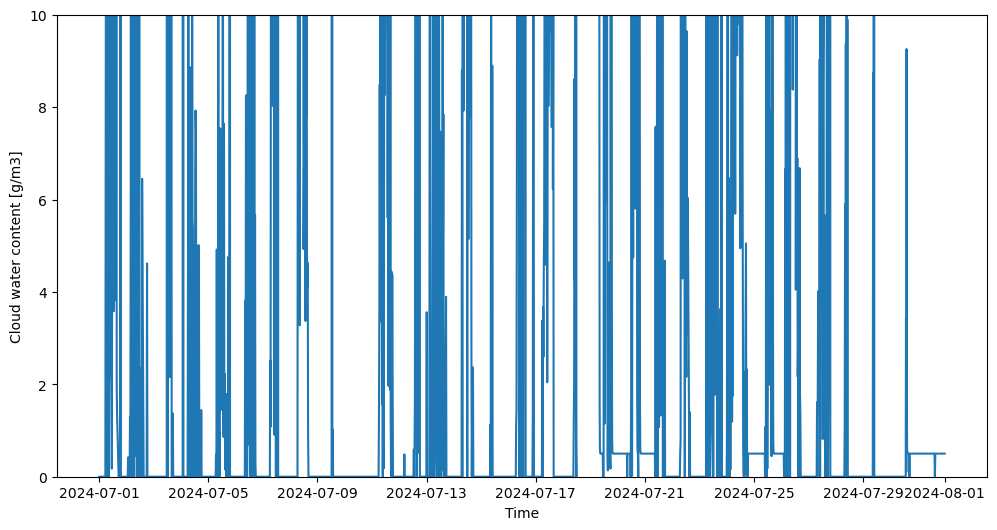

In [187]:
plt.figure(figsize=(12,6))
plt.plot(time,X/Z_c*1000)
plt.ylabel('Cloud water content [g/m3]')
plt.xlabel('Time')
plt.ylim(0,10)

Text(0, 0.5, 'Cloud water content [kg/m2]')

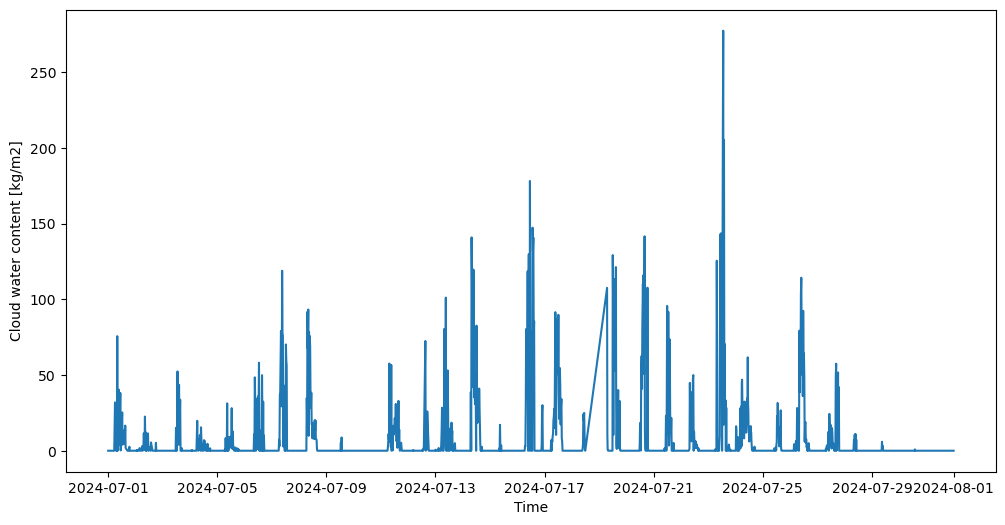

In [188]:
plt.figure(figsize=(12,6))
plt.plot(time,X)
plt.xlabel('Time')
plt.ylabel('Cloud water content [kg/m2]')

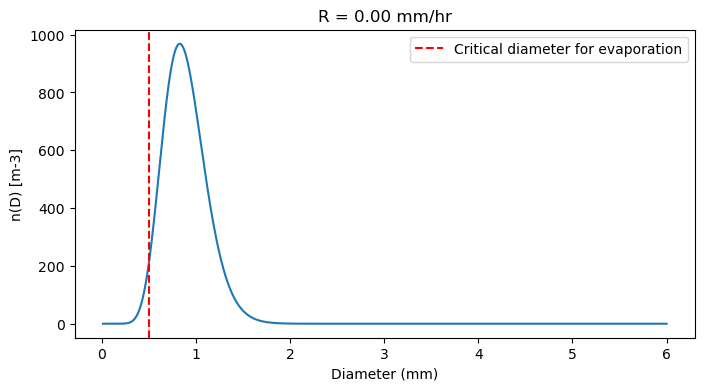

In [189]:
D = np.linspace(0.001,0.6,1000)
N = 6e4 * np.exp(3.2 * mu_result)* D**(mu_result)*np.exp(-Lambda_result*D)#plt.ylim(0,100)

plt.figure(figsize=(8,4))
plt.title(f'R = {R[i] * 3600:.2f} mm/hr')
plt.plot(D*10,N)
plt.axvline(x=D_critical*1000,color='r',linestyle='--',label='Critical diameter for evaporation')
plt.xlabel('Diameter (mm)')
plt.ylabel('n(D) [m-3]')
plt.legend()